<a href="https://colab.research.google.com/github/Rems-dev1/lab-3-feedforward-networks/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Starting
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

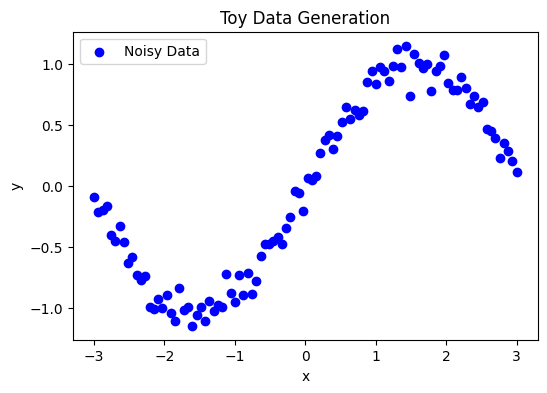

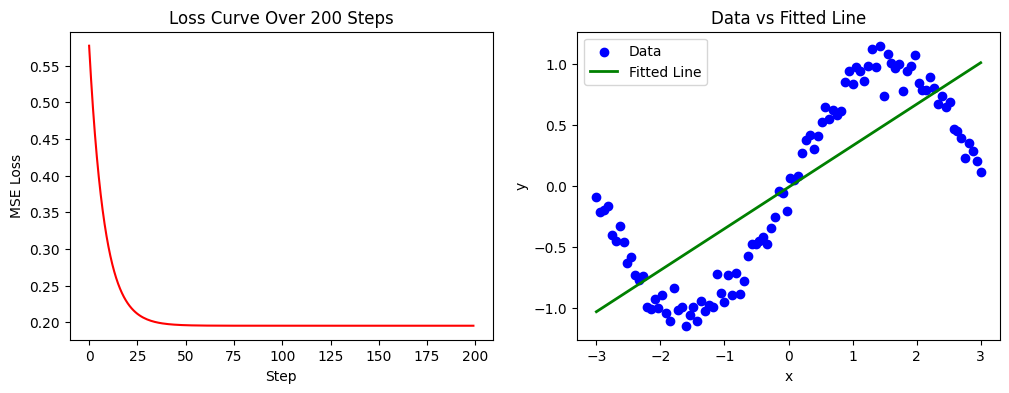

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Noisy Data')
plt.title('Toy Data Generation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
for step in range(200):
    y_hat = w * x + b

    # mse
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #  calculat gradient
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # update weights and bias using learning rate
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(12, 4))

# Plot (a) Loss Curve
plt.subplot(1, 2, 1)
plt.plot(losses, color='red')
plt.title('Loss Curve Over 200 Steps')
plt.xlabel('Step')
plt.ylabel('MSE Loss')

# Plot (b) Fitted Line
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, w * x + b, color='green', linewidth=2, label='Fitted Line')
plt.title('Data vs Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Student Reasoning — The single neuron**

The loss function is

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2.
$$

Where the y  with hat is:

$$
\hat{y}_i=wx_i+b.
$$

Substituting that y_hat into the loss function:

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(wx_i+b-y_i)^2.
$$

taking the partial derivative with respect to \(w\).

Using the chain rule,

$$
\frac{\partial}{\partial w}(u^2)=2u\frac{\partial u}{\partial w},
$$

where

$$
u=wx_i+b-y_i.
$$

Since xi, b, and yi are constants with respect to w, their derivative will be:

$$
\frac{\partial}{\partial w}(wx_i+b-y_i)=x_i.
$$


Therefore,

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(wx_i+b-y_i)x_i.
$$

Since

$$
\hat{y}_i=wx_i+b,
$$

the equation can also be written as

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i)x_i.
$$

taking the partial derivative with respect to \(b\).

The derivative of the inside term is

$$
\frac{\partial}{\partial b}(wx_i+b-y_i)=1.
$$

So,

$$
\frac{\partial \text{Loss}}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i).
$$

These equations match the code because `np.mean()` calculates the average over all data points.


This is underfitting because the model is too simple to fit the data. A single neuron uses the equation y=wx+b, so it can only draw a straight line. A sine wave is a curved line that goes up and down. Because of this, a straight line cannot match the sine wave well. Even if we train the model for a longer time, it still cannot fit the sine wave because the model is too simple.


**Part 1.2 — Hidden layers and activations: why depth helps**

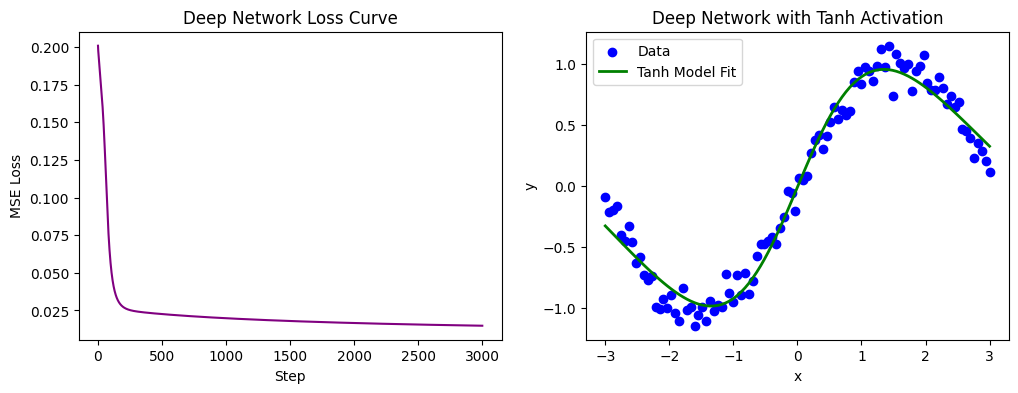

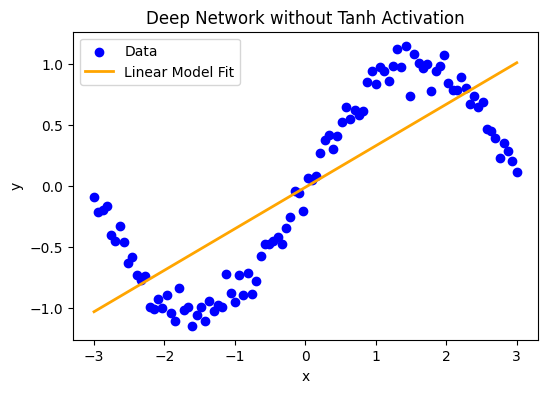

In [3]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

# Reshape input data arrays to matrices for matrix multiplication
x_matrix = x.reshape(-1, 1)
y_matrix = y.reshape(-1, 1)

lr = 0.05
losses_deep = []

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
for step in range(3000):
    # TODO: Forward pass (keep the intermediate values — you need them for backprop):
    #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    #   h  = np.tanh(z1)        # activation
    #   y_hat = h @ W2 + b2     # output, shape (100, 1)
    #   loss  = np.mean((y_hat - y) ** 2)
    z1 = x_matrix @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_matrix) ** 2)
    losses_deep.append(loss)

    # TODO: Backward pass (the chain rule, layer by layer):
    #   d_yhat = 2 * (y_hat - y) / len(y)
    #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    #   dh  = d_yhat @ W2.T
    #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    #   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    N = len(y_matrix)
    d_yhat = 2 * (y_hat - y_matrix) / N
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_matrix.T @ dz1
    db1 = dz1.sum(axis=0)

    # Param updates
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_deep, color='purple')
plt.title('Deep Network Loss Curve')
plt.xlabel('Step')
plt.ylabel('MSE Loss')

plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat, color='green', linewidth=2, label='Tanh Model Fit')
plt.title('Deep Network with Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Re-running the experiment with Tanh removed
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((8,))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1,))
losses_linear = []

for step in range(3000):
    z1_lin = x_matrix @ W1_lin + b1_lin
    h_lin = z1_lin # Tanh activation function is removed here
    y_hat_lin = h_lin @ W2_lin + b2_lin

    loss_lin = np.mean((y_hat_lin - y_matrix) ** 2)
    losses_linear.append(loss_lin)

    d_yhat_lin = 2 * (y_hat_lin - y_matrix) / len(y_matrix)
    dW2_lin = h_lin.T @ d_yhat_lin
    db2_lin = d_yhat_lin.sum(axis=0)

    dh_lin = d_yhat_lin @ W2_lin.T
    dz1_lin = dh_lin * 1.0  # derivative of a linear activation is 1
    dW1_lin = x_matrix.T @ dz1_lin
    db1_lin = dz1_lin.sum(axis=0)

    W1_lin = W1_lin - lr * dW1_lin
    b1_lin = b1_lin - lr * db1_lin
    W2_lin = W2_lin - lr * dW2_lin
    b2_lin = b2_lin - lr * db2_lin

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat_lin, color='orange', linewidth=2, label='Linear Model Fit')
plt.title('Deep Network without Tanh Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**

1.**With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.**
- If the `tanh` activation is removed, the network only uses linear calculations.

$$
y = (x \cdot W_1 + b_1) \cdot W_2 + b_2
$$

This can be simplified to

$$
y = x \cdot W_{new} + b_{new},
$$

where

$$
W_{new} = W_1 \cdot W_2
$$

and

$$
b_{new} = b_1 \cdot W_2 + b_2.
$$

- This means the whole network becomes just one linear model. Even though there are 8 hidden neurons, the network can still only learn a straight line. Because of this, it cannot fit the curved sine wave well.

2.**What role did the hidden layer's 8 neurons play in fitting the curve?**

- The 8 hidden neurons each learn a different part of the pattern. After the `tanh` activation, each neuron produces a different curved output. The output layer combines these curves to make a shape that is close to the sine wave.

3.**This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?**

- Backpropagation is the process of sending the error from the output layer back through the network. It uses the chain rule to calculate how each weight affects the error , so the weights can be updated and the model can learn.


**Part 1.3 — The learning rate: too cold, too hot, just right**

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_4861/2763723554.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_matrix) ** 2)
/tmp/ipykernel_4861/2763723554.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_4861/2763723554.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


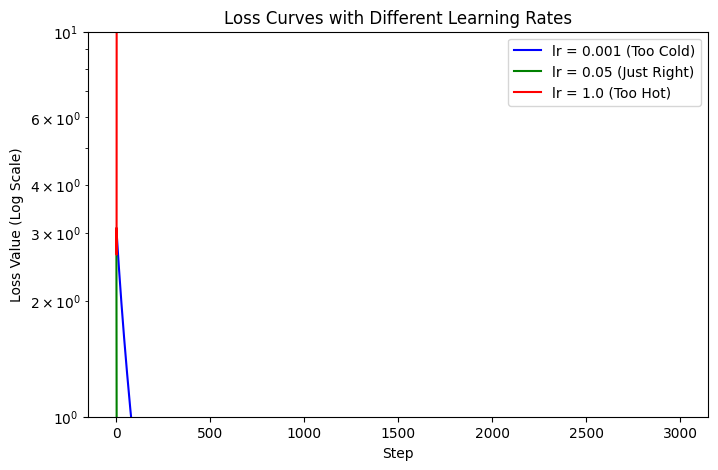

In [4]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE) # I used np.random.seed() so that the model starts with the same random weights every time it trains.
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1,))

    x_matrix = x.reshape(-1, 1)
    y_matrix = y.reshape(-1, 1)

    run_losses = []
    for step in range(steps):
        z1 = x_matrix @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_matrix) ** 2)
        run_losses.append(loss)

        d_yhat = 2 * (y_hat - y_matrix) / len(y_matrix)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_matrix.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2
    return run_losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_low = train_toy(lr=0.001, steps=3000)
losses_mid = train_toy(lr=0.05, steps=3000)
losses_high = train_toy(lr=1.0, steps=3000)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8, 5))
plt.plot(losses_low, label='lr = 0.001 (Too Cold)', color='blue')
plt.plot(losses_mid, label='lr = 0.05 (Just Right)', color='green')
plt.plot(losses_high, label='lr = 1.0 (Too Hot)', color='red')
plt.yscale('log')
plt.title('Loss Curves with Different Learning Rates')
plt.xlabel('Step')
plt.ylabel('Loss Value (Log Scale)')
plt.legend()
plt.show()

**Student Reasoning — Learning rate**

1.**Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?**

- The lr = 0.001 curve goes down very slowly because the learning rate is too small. The model makes only tiny changes to the weights, so it learns slowly.

- The lr = 0.05 curve drops quickly and reaches a low loss. This learning rate is a good balance because the model learns fast without becoming unstable.

- The lr = 1.0 curve increases very quickly and the loss becomes very large. The learning rate is too high, so the weight updates are too big. Instead of moving toward the minimum loss, the updates jump past it. This makes the model unstable, causing the loss to grow instead of getting smaller.


A learning rate that is too large makes very big changes to the weights. These update jump over the lowest point of the loss instead of movin closer to it. Because of this, the model can not settle at the minimum, and the loss may keep increasing or bounce back and forth. Instead of learning faster, the training becomes unstable.


**Section 2 — A Real Feedforward Network in PyTorch**

**Part 2.1 — Preprocess and split (recycled from Lab 2)**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# Binary columns conversion
binary_cols = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Multi-class categorical features processing
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_mtrans = LabelEncoder()
df['MTRANS'] = le_mtrans.fit_transform(df['MTRANS'])

# Ordinal mapping based on consumption frequencies
frequency_mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df['CAEC'] = df['CAEC'].map(frequency_mapping)
df['CALC'] = df['CALC'].map(frequency_mapping)

# Target processing
le_target = LabelEncoder()
df['NObeyesdad'] = le_target.fit_transform(df['NObeyesdad'])

X = df.drop(columns=['NObeyesdad']).values
y = df['NObeyesdad'].values

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**Student Reasoning — Architecture**

1.**Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?**
- CrossEntropyLoss needs the class labels as integers because PyTorch uses the number to know which class is correct. This is simpler and uses less memory than using one-hot vectors.

2.**A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.**

- Neural networks need feature scaling because the gradients depend on the input values. If one feature has much bigger numbers than another, the updates to the weights can become too big, and this can make training harder. Random forests do not need scaling because they split one feature at a time using threshold values.

3.**What does shuffle=True on the training DataLoader do, and why does it help?**

- Setting shuffle=True mixes the training data into random order. This helps the network learn better and stops it from learning patterns based only on the order of the data.


**Part 2.2 — Design the network**

In [6]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu1(out)
        out = self.layer2(out)
        out = self.relu2(out)
        logits = self.output_layer(out)
        return logits

# TODO: Instantiate, move to DEVICE, print the model.
input_features_count = X_train.shape[1]
model = FeedForwardNet(input_dim=input_features_count)
model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters counted by PyTorch:", total_parameters)
print("Layer 1 calculated manual parameter total:", input_features_count * 64 + 64)

FeedForwardNet(
  (layer1): Linear(in_features=16, out_features=64, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
)
Total parameters counted by PyTorch: 3399
Layer 1 calculated manual parameter total: 1088


**Student Reasoning — Architecture**
1. **Show the by-hand parameter count for every layer and confirm it matches PyTorch.**
- Layer 1: (16×64) weights + 64 biases = 1024+64=1088 parameters
- Layer 2: (64×32) weights + 32 biases = 2048+32=2080 parameters
- Output Layer: (32×7) weights + 7 biases = 224+7=231 parameters

- Total parameters: 1088+2080+231=3399

- This matches the PyTorch parameter count, so  calculation is correct.
2. **Why ReLU here instead of the tanh you used in Section 1? Name one advantage.**
- The ReLU function is much faster to calculate than tanh because it only turns negative numbers to zero. It also avoids vanishing gradients during training when inputs are large and positive.


3. **What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)**

- If the ReLU functions are removed, the network becomes linear model. This means it  learn simple linear relationships and cannot learn more complex patterns in the data.



**Part 2.3 — The training loop***

Epoch 01 | Train Loss: 0.0204 | Train Acc: 1.0000 | Val Loss: 0.2030 | Val Acc: 0.9360
Epoch 02 | Train Loss: 0.0194 | Train Acc: 1.0000 | Val Loss: 0.2092 | Val Acc: 0.9360
Epoch 03 | Train Loss: 0.0170 | Train Acc: 1.0000 | Val Loss: 0.2129 | Val Acc: 0.9336
Epoch 04 | Train Loss: 0.0154 | Train Acc: 1.0000 | Val Loss: 0.2182 | Val Acc: 0.9360
Epoch 05 | Train Loss: 0.0160 | Train Acc: 1.0000 | Val Loss: 0.2344 | Val Acc: 0.9336
Epoch 06 | Train Loss: 0.0132 | Train Acc: 1.0000 | Val Loss: 0.2263 | Val Acc: 0.9408
Epoch 07 | Train Loss: 0.0127 | Train Acc: 1.0000 | Val Loss: 0.2170 | Val Acc: 0.9360
Epoch 08 | Train Loss: 0.0119 | Train Acc: 1.0000 | Val Loss: 0.2209 | Val Acc: 0.9384
Epoch 09 | Train Loss: 0.0105 | Train Acc: 1.0000 | Val Loss: 0.2290 | Val Acc: 0.9408
Epoch 10 | Train Loss: 0.0104 | Train Acc: 1.0000 | Val Loss: 0.2305 | Val Acc: 0.9336
Epoch 11 | Train Loss: 0.0121 | Train Acc: 1.0000 | Val Loss: 0.2265 | Val Acc: 0.9336
Epoch 12 | Train Loss: 0.0085 | Train Acc: 

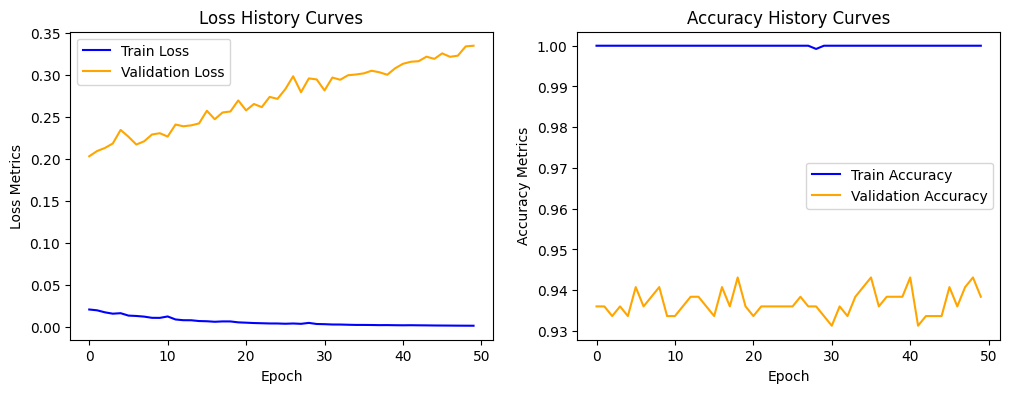

In [8]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# I did a little research and adam makes faster training
train_loss_history = []
val_loss_history = []
train_accuracy_history = []
val_accuracy_history = []
max_val_accuracy = 0.0

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        # Evaluate metrics on training set
        total_train_loss = 0.0
        train_correct_counts = 0
        total_train_samples = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            output = model(xb)
            total_train_loss += criterion(output, yb).item() * xb.size(0)
            predictions = torch.argmax(output, dim=1)
            train_correct_counts += (predictions == yb).sum().item()
            total_train_samples += xb.size(0)
        epoch_train_loss = total_train_loss / total_train_samples
        epoch_train_accuracy = train_correct_counts / total_train_samples

        # Evaluate metrics on validation set
        total_val_loss = 0.0
        val_correct_counts = 0
        total_val_samples = 0
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            output = model(xb)
            total_val_loss += criterion(output, yb).item() * xb.size(0)
            predictions = torch.argmax(output, dim=1)
            val_correct_counts += (predictions == yb).sum().item()
            total_val_samples += xb.size(0)
        epoch_val_loss = total_val_loss / total_val_samples
        epoch_val_accuracy = val_correct_counts / total_val_samples

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    val_accuracy_history.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_accuracy:.4f}")

    # TODO: Save the best model (highest validation accuracy):
    #   torch.save(model.state_dict(), \"ffn_best.pt\")
    if epoch_val_accuracy > max_val_accuracy:
        max_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.title('Loss History Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss Metrics')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_history, label='Train Accuracy', color='blue')
plt.plot(val_accuracy_history, label='Validation Accuracy', color='orange')
plt.title('Accuracy History Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Metrics')
plt.legend()

plt.show()

**Student Reasoning — Experiments**
1. **Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?**

- logits = model(xb) is the forward pass. It calculates the model's predictions, just like the forward calculations in the NumPy code.

- loss.backward() computes the gradients. It finds the gradients for the weights and biases, like the backpropagation steps in the NumPy code.

- optimizer.step() is the update rule. It updates the weights using the gradients so the model can learn.

2. **Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.**

- The model is overfitting. The training loss goes down from about 0.02 to almost 0.00, but the validation loss goes up from about 0.20 to about 0.34. The training accuracy stays at about 100%, while the validation accuracy stays around 93%–94%. This means the model learns the training data very well, but it does not improve on the validation data.

3. **Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?**

- We call optimizer.zero_grad() to clear the old gradients before each batch. If we do not use it, the gradients from the previous batch are added to the new ones. This makes the weight updates incorrect and can make the model train poorly.


**Part 2.4 — Experiments: how training choices change the outcome**

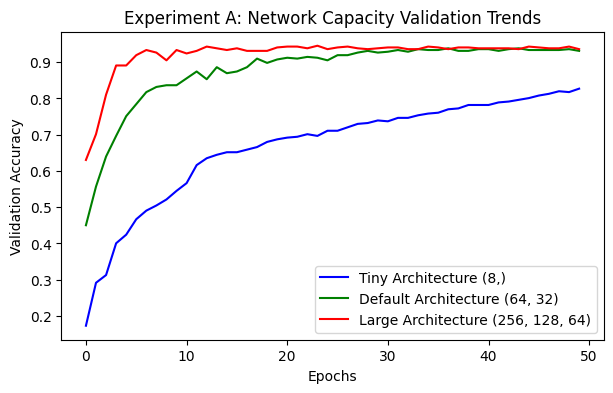

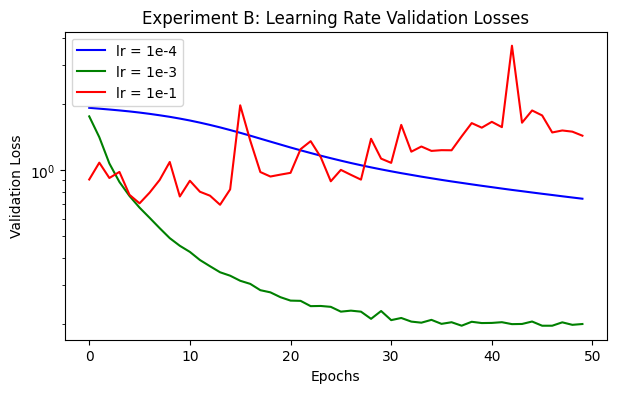

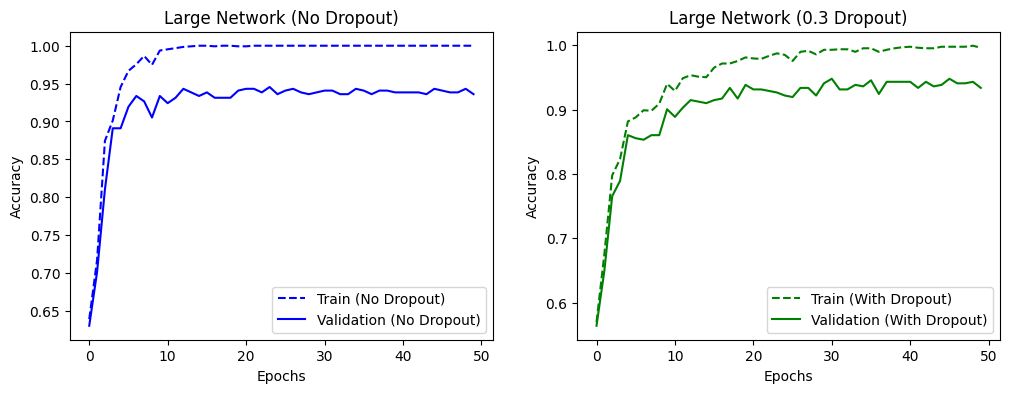

In [9]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

class CustomizableNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout_rate=0.0):
        super(CustomizableNet, self).__init__()
        layers = []
        current_dim = input_dim
        for size in hidden_sizes:
            layers.append(nn.Linear(current_dim, size))
            layers.append(nn.ReLU())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = size
        layers.append(nn.Linear(current_dim, n_classes))
        self.network_sequence = nn.Sequential(*layers)

    def forward(self, x):
        return self.network_sequence(x)

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)
    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    exp_model = CustomizableNet(input_dim=input_features_count, hidden_sizes=hidden_sizes, dropout_rate=dropout)
    exp_model.to(DEVICE)

    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        exp_model.train()
        for xb, yb in exp_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            exp_optimizer.zero_grad()
            output = exp_model(xb)
            loss = exp_criterion(output, yb)
            loss.backward()
            exp_optimizer.step()

        exp_model.eval()
        with torch.no_grad():
            # Calculate train accuracy
            correct_t, total_t = 0, 0
            for xb, yb in exp_train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                correct_t += (torch.argmax(logits, dim=1) == yb).sum().item()
                total_t += xb.size(0)

            # Calculate validation loss and accuracy
            correct_v, total_v, loss_v = 0, 0, 0.0
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss_v += exp_criterion(logits, yb).item() * xb.size(0)
                correct_v += (torch.argmax(logits, dim=1) == yb).sum().item()
                total_v += xb.size(0)

        history['train_acc'].append(correct_t / total_t)
        history['val_acc'].append(correct_v / total_v)
        history['val_loss'].append(loss_v / total_v)

    return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
result_tiny = run_experiment(hidden_sizes=(8,))
result_default = run_experiment(hidden_sizes=(64, 32))
result_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(7, 4))
plt.plot(result_tiny['val_acc'], label='Tiny Architecture (8,)', color='blue')
plt.plot(result_default['val_acc'], label='Default Architecture (64, 32)', color='green')
plt.plot(result_large['val_acc'], label='Large Architecture (256, 128, 64)', color='red')
plt.title('Experiment A: Network Capacity Validation Trends')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
result_lr_slow = run_experiment(lr=1e-4)
result_lr_good = run_experiment(lr=1e-3)
result_lr_fast = run_experiment(lr=1e-1)

plt.figure(figsize=(7, 4))
plt.plot(result_lr_slow['val_loss'], label='lr = 1e-4', color='blue')
plt.plot(result_lr_good['val_loss'], label='lr = 1e-3', color='green')
plt.plot(result_lr_fast['val_loss'], label='lr = 1e-1', color='red')
plt.yscale('log')
plt.title('Experiment B: Learning Rate Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
large_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
large_with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(large_no_dropout['train_acc'], label='Train (No Dropout)', linestyle='--', color='blue')
plt.plot(large_no_dropout['val_acc'], label='Validation (No Dropout)', color='blue')
plt.title('Large Network (No Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(large_with_dropout['train_acc'], label='Train (With Dropout)', linestyle='--', color='green')
plt.plot(large_with_dropout['val_acc'], label='Validation (With Dropout)', color='green')
plt.title('Large Network (0.3 Dropout)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Student Reasoning — Experiments**

 1. **Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?**
- No, the largest network did not win clearly. It got almost 100% train accuracy, but validation stayed around 94%. This shows some overfitting. Bigger network did not give much better results.

 2. **Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?**
 Yes, it is similar to Part 1.3.
- 1e-4 learns too slow.
- 1e-3 learns best and stable.
- 1e-1 is too big and makes training unstable.


 3. **Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.**

 - Dropout made the gap smaller. Without dropout, train accuracy was near 100% but validation was about 94%. Dropout turns off some neurons during training, so the model does not depend on only some neurons and overfit less.